In [40]:
import py


In [41]:
import pandas as pd        # data handling
import numpy as np         # numerical operations
import scipy.stats as stats # inferential statistics
import matplotlib.pyplot as plt  # plots

In [42]:
pwd

'C:\\Users\\ajayi\\Desktop\\python_data_analysis'

In [4]:
cd Desktop 

C:\Users\ajayi\Desktop


In [5]:
pwd

'C:\\Users\\ajayi\\Desktop'

In [6]:
cd python_data_analysis

C:\Users\ajayi\Desktop\python_data_analysis


In [43]:
data = pd.read_excel("dataset_cord_care_analyze.xlsx")

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 97 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   health_facility                             350 non-null    object 
 1   sex                                         351 non-null    object 
 2   age_of_child_cat                            352 non-null    object 
 3   child_weight_today                          351 non-null    float64
 4   parents_religion                            352 non-null    object 
 5   ethnicity                                   352 non-null    object 
 6   residence                                   351 non-null    object 
 7   residenceL                                  351 non-null    object 
 8   residenceLR                                 351 non-null    float64
 9   mother_hlfe                                 352 non-null    object 
 10  mother_hlfe_2c

In [28]:
import openpyxl

# 1. Check the true physical dimensions of the Excel sheet from the file system
wb = openpyxl.load_workbook("dataset_cord_care_analyze.xlsx", read_only=True)
sheet = wb.active
print(f"--- Excel File Properties ---")
print(f"Total physical rows in Excel sheet: {sheet.max_row}")
print(f"Total physical columns in Excel sheet: {sheet.max_column}\n")

# 2. Check if pandas is dropping rows during import due to blank lines at the bottom
print(f"--- Pandas DataFrame Shape ---")
print(f"Rows loaded by pandas: {data.shape[0]} (excluding header row)")
print(f"Columns loaded by pandas: {data.shape[1]}\n")

# 3. Look for hidden NaN or completely empty rows in your dataframe
empty_rows = data.isnull().all(axis=1).sum()
print(f"--- Blank Row Check ---")
print(f"Number of completely blank rows found and skipped: {empty_rows}")

# 4. Check the true range of your dataframe index values
print(f"\nDataFrame Index Range: Minimum index = {data.index.min()}, Maximum index = {data.index.max()}")

--- Excel File Properties ---
Total physical rows in Excel sheet: 353
Total physical columns in Excel sheet: 97

--- Pandas DataFrame Shape ---
Rows loaded by pandas: 350 (excluding header row)
Columns loaded by pandas: 97

--- Blank Row Check ---
Number of completely blank rows found and skipped: 0

DataFrame Index Range: Minimum index = 1, Maximum index = 351


In [29]:
# Load the raw file with no type conversions to prevent skipping rows
raw_test = pd.read_excel("dataset_cord_care_analyze.xlsx", keep_default_na=False)

print(f"Forced load shape: {raw_test.shape}")
print(f"Difference: {raw_test.shape[0] - data.shape[0]} row(s)")

# Display the absolute last 5 rows of the Excel sheet to find the anomalies
raw_test.tail(5)

Forced load shape: (352, 97)
Difference: 2 row(s)


,health_facility,sex,age_of_child_cat,child_weight_today,parents_religion,ethnicity,residence,residenceL,residenceLR,mother_hlfe,mother_hlfe_2cat,mother_hlfeLR,father_hlfe,mother_occupation,mother_occupationL,mother_occupationLR,father_occupation,mother_age,mother_age_cat,parity,parity_cat,parity_2ca2t,parity_catLR,mother_marital_status,attended_anc_in_preg,visit_no,visit_no_cat,adequate_anc,adequate_ancLR,place_of_anc,place_of_anc_2_cat,place_of_ancLR,had_health_talk_on_ucc,place_of_birth_of_index_child,place_of_birth_2cat,place_of_birthLR,child_bw,child_bw_cat,object_used_to_cut_cord,what_was_applied_to_the_cord_after_cut,thread_soaked_in_metspirit,age_at_cord_dropped,aware_of_ucc,wash_hands_before_cord_care,agent_used_to_clean_cord_before_drop,Hot_water_compress,cotton_wool,methylated_spirit_only,chlorhexidine_gel_only,use_CLGcorrect_LR,use_CLGcorrect,toooth_paste,shea_butter,metholatum,herbs/local_concortion,practice_outcome,practice_outcomeLR,multi_agent,freq_of_metspirit_use_in_a_day_cat,freq_of_chlorhexidine_use_in_a_day_cat,taught_on_chlorhexidine_app,sure_using_chlorhexidine_correctly,good_to_expose_cord_to_fresh_air,good_to_expose_cord_to_keep_cord_in_diaper,agent_applied_after_cord_drop,safe_postsep_care,safe_postsep_careLR,multiple_agent_applied_after_cord_drop,Chlorhexidine gel,3,4,5,6,7,duration_of_cord_care_practice_cat,tiime_intended_to_stop_cat,Post_sep_counsel,Post_sep_counselLR,who_told_you,Previous_exp_source,sister_source,multiple_source,Grandmother_source,Other_Mothers_source,Friends_source,Healthcareworkers_source,Healthcareworkers_source2cat,Healthcareworkers_sourceLR,Internet_source,who_decides_how_to_care_for_the_child_cc,self_decision_2cat,self_decisionLR,multiple,2,3.1,4.1,5.1
347,EKSUTH,M,>12 months,10,Christianity,YORUBA,ADO,Urban,1,Tertiary,higher education,1,Tertiary,unspecified,Unemployed,0,unspecified,20,<=20yr,1,1,primi,0,Single,Yes,11,>=8,Yes,1,PHC,Healthcare facility,1,Yes,Private Hospital,Healthcare facility,1,3.5,2.5-3.9,I don’t know,Cord clamp,,7 - 14 days,Yes,Yes,0,0,0,0,1,1,Yes,0,0,0,0,Safe,1,No,,2 or more times a day,Yes,Yes,No,No,,Yes,1,No,Chlorhexidine gel,,,,,,14 - 30 days,,,,,0,0,No,0,0,1,0,Informal,0,0,,,,,,,,
348,EKSUTH,M,7-12 months,8.5,Christianity,YORUBA,ADO,Urban,1,Tertiary,higher education,1,Tertiary,Civil servant,Formal sector employment,1,Civil servant,32,31-40yr,2,2 - 4,mulitipara,1,Married,Yes,10,>=8,Yes,1,EKSUTH,Healthcare facility,1,Yes,EKSUTH,Healthcare facility,1,2.8,2.5-3.9,I don’t know,Cord clamp,,<7 days,Yes,Yes,0,0,0,1,0,0,No,0,0,0,0,Safe,1,No,>= 3 times a day,,,,Don’t know,Don’t know,,No,0,Yes,,Continue to clean with Methylated Spirit,,Mentholatum/ Robb,,,> 1 month,,No,0,,1,0,Yes,1,0,0,0,Informal,0,0,Myself,Yes,1,No,,,,
349,EKSUTH,F,1-6 months,5,Islam,YORUBA,ADO,Urban,1,Tertiary,higher education,1,Tertiary,Businesswoman,Informal sector/self employed,1,Civil servant,23,21-30yr,1,1,primi,0,Married,Yes,6,4 - 7,Yes,1,General hospital,Healthcare facility,1,Yes,General Hospital,Healthcare facility,1,,,I don’t know,Cord clamp,,<7 days,Yes,Yes,0,0,0,0,1,1,Yes,0,0,0,0,Safe,1,No,,once a day,Yes,Yes,No,No,,No,0,No,,,,,Shea Butter,,> 1 month,,No,0,,0,0,No,1,0,0,0,Informal,0,0,,No,0,No,,Mother-in-law,,
350,EKSUTH,M,7-12 months,6,Islam,YORUBA,ADO,Urban,1,Tertiary,higher education,1,Tertiary,Businesswoman,Informal sector/self employed,1,Civil servant,30,21-30yr,1,1,primi,0,Married,Yes,6,4 - 7,Yes,1,General hospital,Healthcare facility,1,Yes,PHC/CHC,Healthcare facility,1,2.7,2.5-3.9,Scissors,Cord clamp,,7 - 14 days,Yes,Yes,0,0,0,0,1,1,Yes,0,0,0,0,Safe,1,No,,2 or more times a day,Yes,Yes,No,No,,No,0,Yes,,Continue to clean with Methylated Spirit,,,,Vaseline,> 1 month,,No,0,,0,0,No,0,0,0,1,Formal HCW,1,0,Myself,Yes,1,No,,,,
351,EKSUTH,M,<1 month,4,Christianity,EBIRA,ADO,Urban,1,Tertiary,higher education,1,Tertiary,Full time house wife,Homemaker,0,Unemployed,27,21-30yr,1,1,primi,0,Separated,Yes,7,4 - 7,Yes,1,General hospital,Healthcare facility,1,No,PHC/CHC,Healthcare facility,1,3

In [30]:
# Extract the two rows that pandas originally skipped (index 350 and 351)
corrupted_rows = raw_test.iloc[350:352]

# Print them out column by column, ignoring empty/nan fields, to see what's in them
for idx, row in corrupted_rows.iterrows():
    print(f"\n=== CRITICAL CHECK: DATA INSIDE ROW {idx+1} ===")
    valid_entries = {col: val for col, val in row.items() if str(val).strip() != ""}
    for col, val in list(valid_entries.items())[:10]: # Showing first 10 fields to keep it readable
        print(f"{col}: {val}")


=== CRITICAL CHECK: DATA INSIDE ROW 351 ===
health_facility: EKSUTH
sex: M
age_of_child_cat: 7-12 months
child_weight_today: 6
parents_religion: Islam
ethnicity: YORUBA
residence: ADO
residenceL: Urban
residenceLR: 1
mother_hlfe: Tertiary

=== CRITICAL CHECK: DATA INSIDE ROW 352 ===
health_facility: EKSUTH
sex: M
age_of_child_cat: <1 month
child_weight_today: 4
parents_religion: Christianity
ethnicity: EBIRA
residence: ADO
residenceL: Urban
residenceLR: 1
mother_hlfe: Tertiary


In [24]:
data.head()
data.describe()

,child_weight_today,mother_hlfeLR,mother_occupationLR,mother_age,parity,parity_catLR,visit_no,adequate_ancLR,place_of_ancLR,child_bw,Hot_water_compress,cotton_wool,methylated_spirit_only,chlorhexidine_gel_only,use_CLGcorrect_LR,toooth_paste,shea_butter,metholatum,herbs/local_concortion,practice_outcomeLR,safe_postsep_careLR,Post_sep_counselLR,Previous_exp_source,sister_source,Grandmother_source,Other_Mothers_source,Friends_source,Healthcareworkers_source,Internet_source
count,349.000000,350.000000,348.000000,350.000000,350.000000,350.000000,350.000000,350.000000,344.000000,295.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,345.000000,333.000000,311.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,5.677765,0.920000,0.867816,30.260000,2.082857,0.634286,5.468571,0.777143,0.909884,3.039085,0.142857,0.002857,0.680000,0.194286,0.151429,0.031429,0.062857,0.108571,0.008571,0.652174,0.561562,0.234727,0.269795,0.002933,0.272727,0.043988,0.043988,0.507331,0.014663
std,1.992747,0.271682,0.339178,5.431348,1.110767,0.482319,2.210391,0.416759,0.286765,0.509597,0.350428,0.053452,0.467144,0.396216,0.358979,0.174723,0.243053,0.311546,0.092316,0.476972,0.496942,0.424511,0.444505,0.054153,0.446016,0.205370,0.205370,0.500681,0.120375
min,1.930000,0.000000,0.000000,16.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.200000,1.000000,1.000000,27.000000,1.000000,0.000000,4.000000,1.000000,1.000000,2.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.300000,1.000000,1.000000,30.000000,2.000000,1.000000,5.000000,1.000000,1.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,7.000000,1.000000,1.000000,34.000000,3.000000,1.000000,7.000000,1.000000,1.000000,3.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,14.000000,1.000000,1.000000,46.000000,7.000000,1.000000,11.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
# 1. Automatically grab all categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
# 2. Loop through them and print counts and percentages
for col in cat_cols:
    print(f"--- {col} ---")
    
    # Calculate counts
    counts = data[col].value_counts()
    
    # Calculate percentages (normalize=True)
    percents = data[col].value_counts(normalize=True) * 100
    
    # Combine them into a small table for readability
    df_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents})
    print(df_summary)
    print("\n") # Adds a space between columns

--- health_facility ---
                 Count  Percentage (%)
health_facility                       
EKSUTH             241       68.857143
IRE                 47       13.428571
OKEILA              28        8.000000
IGBEMO              24        6.857143
PHC                  7        2.000000
MISSION HOME         3        0.857143


--- sex ---
     Count  Percentage (%)
sex                       
F      190       54.131054
M      161       45.868946


--- age_of_child_cat ---
                  Count  Percentage (%)
age_of_child_cat                       
1-6 months          209       59.375000
7-12 months          78       22.159091
<1 month             43       12.215909
>12 months           22        6.250000


--- parents_religion ---
                  Count  Percentage (%)
parents_religion                       
Christianity        325       92.329545
Islam                27        7.670455


--- ethnicity ---
           Count  Percentage (%)
ethnicity                       
YO

In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'chlorhexidine_gel_only'
factors = ['mother_age_cat', 'parity_cat','mother_hlfe', 'mother_occupationL', 'mother_marital_status', 'parents_religion', 'residenceL', 'place_of_anc_2_cat', 'adequate_anc', 'had_health_talk_on_ucc', 'place_of_birth_2cat', 'Healthcareworkers_source2cat', 'self_decision_2cat'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)
    
    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])
    
    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100
    
    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)
    
    # Display Results
    print("\n--- Frequency Count Table (Counts) ---")
    print(ct_counts)
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))
    
    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")
    
    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: mother_age_cat vs chlorhexidine_gel_only

--- Frequency Count Table (Counts) ---
chlorhexidine_gel_only  0.0  1.0
mother_age_cat                  
21-30yr                 147   40
31-40yr                 112   27
<=20yr                   12    1
>40yr                    11    0
--- Percentage Table (Row %) ---
chlorhexidine_gel_only     0.0    1.0
mother_age_cat                       
21-30yr                  78.61  21.39
31-40yr                  80.58  19.42
<=20yr                   92.31   7.69
>40yr                   100.00   0.00

--- Chi-Square Test Results ---
Chi-Square Statistic: 4.2561
P-value: 0.2351
Degrees of Freedom: 3

Result: Not statistically significant (Fail to reject H0)

ANALYSIS: parity_cat vs chlorhexidine_gel_only

--- Frequency Count Table (Counts) ---
chlorhexidine_gel_only  0.0  1.0
parity_cat                      
1                       102   26
2 - 4                   167   42
>4                       13    0
--- Percentage Table (Row %) ---
chlo

In [46]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# 1. Load Data
df = pd.read_excel("dataset_cord_care_analyze.xlsx")

# 2. Clean/Verify Data Types & Handle Missing Values
df = df.dropna(subset=['chlorhexidine_gel_only'])
df['chlorhexidine_gel_only'] = df['chlorhexidine_gel_only'].astype(int)
df['mother_age'] = pd.to_numeric(df['mother_age'], errors='coerce')

# Define predictors exactly as they appear in your formula definitions
predictors = [
    "C(Healthcareworkers_sourceLR)",
    "C(self_decisionLR)",
    "C(mother_hlfeLR)",
    "C(place_of_birthLR)",
    "C(residenceLR)",
    "mother_age"
]

# --- STEP A: CALCULATE CRUDE ODDS RATIOS (UNIVARIATE) ---
crude_results = []

for pred in predictors:
    # Fit simple logistic regression for a single predictor
    uni_formula = f"chlorhexidine_gel_only ~ {pred}"
    try:
        uni_model = smf.logit(uni_formula, data=df).fit(disp=0)
        
        # Extract odds, confidence intervals, and p-values
        or_val = np.exp(uni_model.params)
        ci_val = np.exp(uni_model.conf_int())
        p_val = uni_model.pvalues
        
        # Combine into a temporary dataframe for this predictor
        pred_df = pd.DataFrame({
            'cOR': or_val,
            'cOR_Lower': ci_val[0],
            'cOR_Upper': ci_val[1],
            'Crude p-value': p_val
        })
        crude_results.append(pred_df)
    except Exception as e:
        print(f"Skipping crude calculation for {pred} due to error: {e}")

# Combine all crude summaries together (excluding the individual intercept rows)
df_crude = pd.concat(crude_results)
df_crude = df_crude[~df_crude.index.str.contains('Intercept')]
import pandas as pd

# --- STEP B: CALCULATE ADJUSTED ODDS RATIOS (MULTIVARIABLE) ---
formula = "chlorhexidine_gel_only ~ " + " + ".join(predictors)
model_mv = smf.logit(formula, data=df).fit()

model_odds = np.exp(model_mv.params)
conf_int = np.exp(model_mv.conf_int())

df_aor = pd.DataFrame({
    'aOR': model_odds,
    'aOR_Lower': conf_int[0],
    'aOR_Upper': conf_int[1],
    'Adjusted p-value': model_mv.pvalues
})

# --- STEP C: MERGE CRUDE AND ADJUSTED TABLES TOGETHER ---
df_final = df_aor.join(df_crude, how='left')

# Reorder columns logically for publication
final_column_order = [
    'cOR', 'cOR_Lower', 'cOR_Upper', 'Crude p-value',
    'aOR', 'aOR_Lower', 'aOR_Upper', 'Adjusted p-value'
]
df_final = df_final.reindex(columns=final_column_order)

# --- FORCE PANDAS TO PRINT IN A SINGLE WIDE LAYOUT ---
pd.set_option('display.width', 1000)       # Tells pandas your screen is very wide
pd.set_option('display.max_columns', None) # Don't truncate columns with "..."

print("\n" + "="*85)
print("FINAL MERGED LOGISTIC REGRESSION TABLE")
print("="*85)
print(df_final.round(3))

Optimization terminated successfully.
         Current function value: 0.428609
         Iterations 8

FINAL MERGED LOGISTIC REGRESSION TABLE
                                        cOR  cOR_Lower  cOR_Upper  Crude p-value    aOR  aOR_Lower  aOR_Upper  Adjusted p-value
Intercept                               NaN        NaN        NaN            NaN  0.059      0.003      1.168             0.063
C(Healthcareworkers_sourceLR)[T.1.0]  2.085      1.192      3.647          0.010  1.234      0.645      2.363             0.525
C(self_decisionLR)[T.1.0]             2.321      1.193      4.518          0.013  1.679      0.803      3.508             0.168
C(mother_hlfeLR)[T.1]                 7.094      0.947     53.157          0.057  2.162      0.237     19.765             0.495
C(place_of_birthLR)[T.1.0]            5.295      1.245     22.530          0.024  4.934      0.600     40.548             0.137
C(residenceLR)[T.1.0]                 4.671      1.810     12.053          0.001  2.807   

In [13]:
!pip install missingno

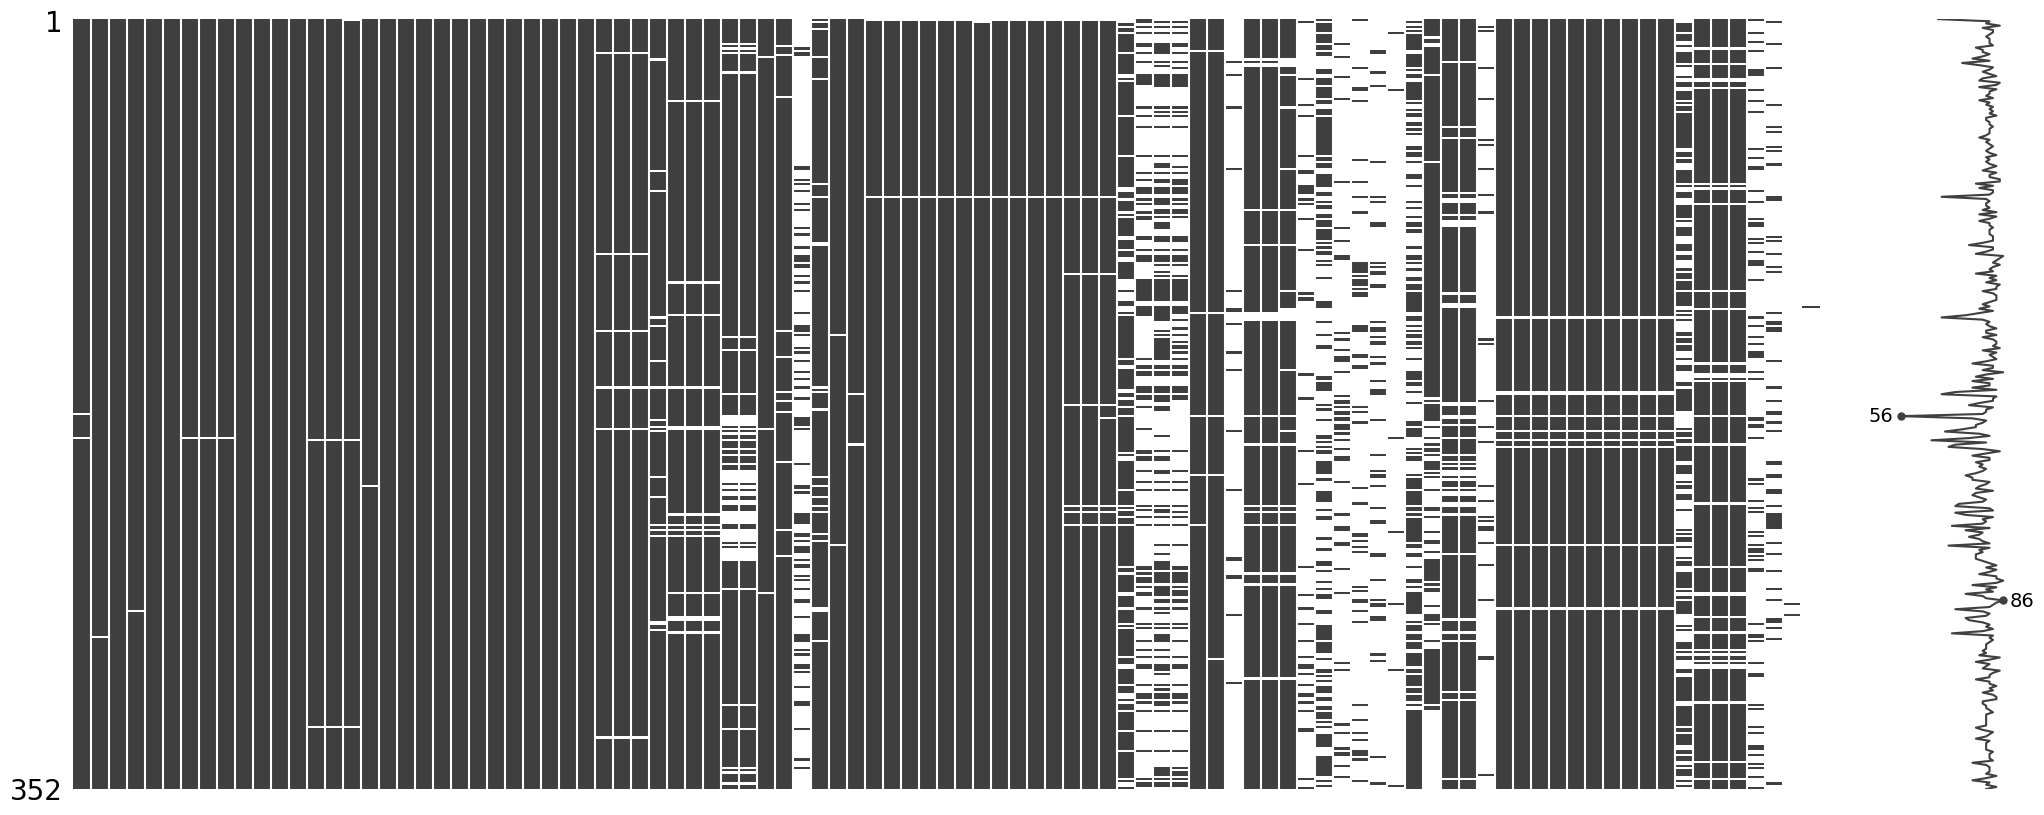

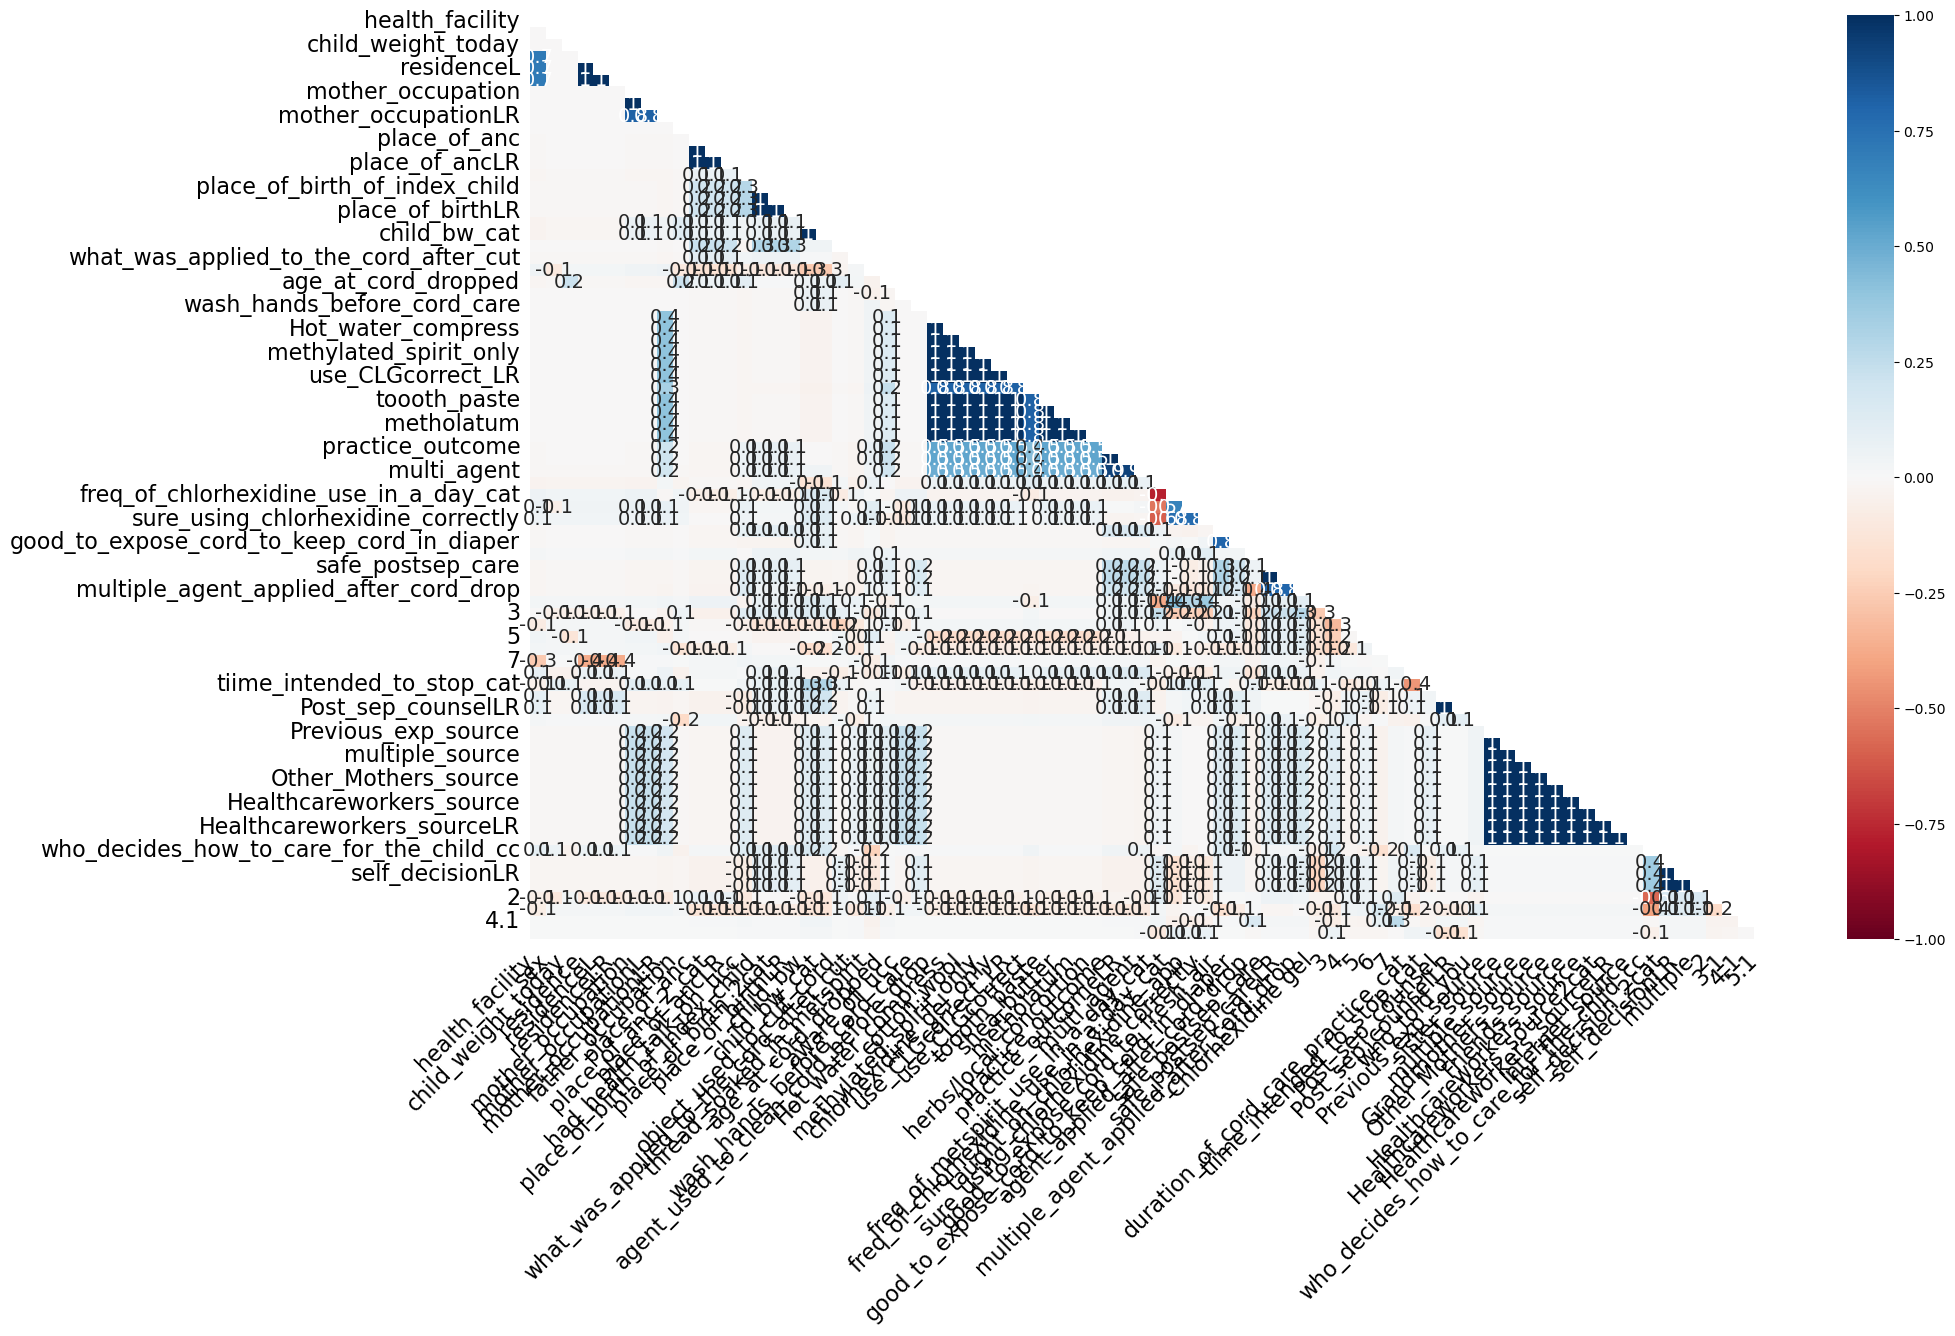

In [14]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizes where the holes in your dataset are
msno.matrix(data)
plt.show()

# Visualizes if missingness in one factor correlates with missingness in another
msno.heatmap(data)
plt.show()

In [15]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# 1. Load Data
df = pd.read_excel("dataset_cord_care_analyze.xlsx")

# 2. Clean/Verify Data Types & Handle Missing Values
df = df.dropna(subset=['chlorhexidine_gel_only'])
df['chlorhexidine_gel_only'] = df['chlorhexidine_gel_only'].astype(int)
df['mother_age'] = pd.to_numeric(df['mother_age'], errors='coerce')

# Define predictors exactly as they appear in your formula definitions
predictors = [
    "C(Healthcareworkers_sourceLR)",
    "C(mother_hlfeLR)",
    "C(place_of_birthLR)",
    "C(residenceLR)",
    "mother_age"
]

# --- STEP A: CALCULATE CRUDE ODDS RATIOS (UNIVARIATE) ---
crude_results = []

for pred in predictors:
    # Fit simple logistic regression for a single predictor
    uni_formula = f"chlorhexidine_gel_only ~ {pred}"
    try:
        uni_model = smf.logit(uni_formula, data=df).fit(disp=0)
        
        # Extract odds, confidence intervals, and p-values
        or_val = np.exp(uni_model.params)
        ci_val = np.exp(uni_model.conf_int())
        p_val = uni_model.pvalues
        
        # Combine into a temporary dataframe for this predictor
        pred_df = pd.DataFrame({
            'cOR': or_val,
            'cOR_Lower': ci_val[0],
            'cOR_Upper': ci_val[1],
            'Crude p-value': p_val
        })
        crude_results.append(pred_df)
    except Exception as e:
        print(f"Skipping crude calculation for {pred} due to error: {e}")

# Combine all crude summaries together (excluding the individual intercept rows)
df_crude = pd.concat(crude_results)
df_crude = df_crude[~df_crude.index.str.contains('Intercept')]
import pandas as pd

# --- STEP B: CALCULATE ADJUSTED ODDS RATIOS (MULTIVARIABLE) ---
formula = "chlorhexidine_gel_only ~ " + " + ".join(predictors)
model_mv = smf.logit(formula, data=df).fit()

model_odds = np.exp(model_mv.params)
conf_int = np.exp(model_mv.conf_int())

df_aor = pd.DataFrame({
    'aOR': model_odds,
    'aOR_Lower': conf_int[0],
    'aOR_Upper': conf_int[1],
    'Adjusted p-value': model_mv.pvalues
})

# --- STEP C: MERGE CRUDE AND ADJUSTED TABLES TOGETHER ---
df_final = df_aor.join(df_crude, how='left')

# Reorder columns logically for publication
final_column_order = [
    'cOR', 'cOR_Lower', 'cOR_Upper', 'Crude p-value',
    'aOR', 'aOR_Lower', 'aOR_Upper', 'Adjusted p-value'
]
df_final = df_final.reindex(columns=final_column_order)

# --- FORCE PANDAS TO PRINT IN A SINGLE WIDE LAYOUT ---
pd.set_option('display.width', 1000)       # Tells pandas your screen is very wide
pd.set_option('display.max_columns', None) # Don't truncate columns with "..."

print("\n" + "="*85)
print("FINAL MERGED LOGISTIC REGRESSION TABLE")
print("="*85)
print(df_final.round(3))

Optimization terminated successfully.
         Current function value: 0.453700
         Iterations 8

FINAL MERGED LOGISTIC REGRESSION TABLE
                                        cOR  cOR_Lower  cOR_Upper  Crude p-value    aOR  aOR_Lower  aOR_Upper  Adjusted p-value
Intercept                               NaN        NaN        NaN            NaN  0.042      0.002      0.797             0.035
C(Healthcareworkers_sourceLR)[T.1.0]  2.085      1.192      3.647          0.010  1.427      0.790      2.575             0.238
C(mother_hlfeLR)[T.1]                 7.094      0.947     53.157          0.057  2.031      0.226     18.228             0.527
C(place_of_birthLR)[T.1.0]            5.295      1.245     22.530          0.024  5.631      0.690     45.921             0.107
C(residenceLR)[T.1.0]                 4.671      1.810     12.053          0.001  3.418      1.237      9.448             0.018
mother_age                            0.979      0.932      1.029          0.402  0.942   

In [57]:
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress visual convergence warnings for cleaner output
warnings.simplefilter("ignore", ConvergenceWarning)

# ==========================================
# STEP 1: LOAD AND CLEAN DATA
# ==========================================
# Load the dataset
df = pd.read_excel("dataset_cord_care_analyze.xlsx")

# Drop rows where the target variable itself is missing
df = df.dropna(subset=['chlorhexidine_gel_only'])

# Clean and verify data types
df['chlorhexidine_gel_only'] = df['chlorhexidine_gel_only'].astype(int)
df['mother_age'] = pd.to_numeric(df['mother_age'], errors='coerce')

# Handle missing data for categorical predictors by filling NaNs with a 'Missing' label
categorical_factors = [
    'self_decisionLR', 
    'Healthcareworkers_sourceLR', 
    'mother_hlfeLR', 
    'place_of_birthLR', 
    'residenceLR'
]

for factor in categorical_factors:
    df[factor] = df[factor].fillna('Missing')

# Define predictors exactly as they should appear in the Patsy formula definitions
predictors = [
    "C(Healthcareworkers_sourceLR)",
    "C(self_decisionLR)",
    "C(mother_hlfeLR)",
    "C(place_of_birthLR)",
    "C(residenceLR)",
    "mother_age"
]

# ==========================================
# STEP 2: CALCULATE CRUDE ODDS RATIOS (UNIVARIATE)
# ==========================================
crude_results = []

for pred in predictors:
    # Fit simple Logistic regression for a single predictor
    uni_formula = f"chlorhexidine_gel_only ~ {pred}"
    try:
        uni_model = smf.logit(uni_formula, data=df).fit(disp=0)
        
        # Extract odds, confidence intervals, and p-values
        or_val = np.exp(uni_model.params)
        ci_val = np.exp(uni_model.conf_int())
        p_val = uni_model.pvalues
        
        # Combine into a temporary dataframe for this predictor
        pred_df = pd.DataFrame({
            'cOR': or_val,
            'cOR_Lower': ci_val[0],
            'cOR_Upper': ci_val[1],
            'Crude p-value': p_val
        })
        crude_results.append(pred_df)
        
    except Exception as e:
        print(f"Skipping crude calculation for {pred} due to error: {e}")

# Combine all crude summaries together and drop Intercept rows
df_crude = pd.concat(crude_results)
df_crude = df_crude.drop('Intercept', errors='ignore')

# ==========================================
# STEP 3: CALCULATE ADJUSTED ODDS RATIOS (MULTIVARIABLE)
# ==========================================
# Construct the full multivariable formula string cleanly
formula = "chlorhexidine_gel_only ~ " + " + ".join(predictors)
model_mv = smf.logit(formula, data=df).fit()

model_odds = np.exp(model_mv.params)
conf_int = np.exp(model_mv.conf_int())

df_aor = pd.DataFrame({
    'aOR': model_odds,
    'aOR_Lower': conf_int[0],
    'aOR_Upper': conf_int[1],
    'Adjusted p-value': model_mv.pvalues
})

# Drop the Intercept row from the multivariable dataframe
df_aor = df_aor.drop('Intercept', errors='ignore')

# ==========================================
# STEP 4: MERGE TABLES AND FORMAT OUTPUT
# ==========================================
# Explicit outer merge on indices ensures perfect row-by-row alignment
df_final = df_aor.merge(df_crude, left_index=True, right_index=True, how='outer')

# Reorder columns logically for medical journal publication
final_column_order = [
    'cOR', 'cOR_Lower', 'cOR_Upper', 'Crude p-value',
    'aOR', 'aOR_Lower', 'aOR_Upper', 'Adjusted p-value'
]
df_final = df_final.reindex(columns=final_column_order)

# Force pandas to print in a single wide layout without truncating
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("\n" + "="*95)
print("FINAL MERGED LOGISTIC REGRESSION TABLE (CRUDE vs ADJUSTED ODDS RATIOS)")
print("="*95)
print(df_final.round(3))

C:\Users\ajayi\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


         Current function value: 0.443871
         Iterations: 35


C:\Users\ajayi\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)



FINAL MERGED LOGISTIC REGRESSION TABLE (CRUDE vs ADJUSTED ODDS RATIOS)
                                            cOR  cOR_Lower  cOR_Upper  Crude p-value    aOR  aOR_Lower  aOR_Upper  Adjusted p-value
C(Healthcareworkers_sourceLR)[T.1.0]      2.085      1.192      3.647          0.010  1.403      0.770      2.557             0.269
C(Healthcareworkers_sourceLR)[T.Missing]  1.801      0.352      9.211          0.480  1.487      0.273      8.108             0.646
C(mother_hlfeLR)[T.1]                     7.094      0.947     53.157          0.057  2.126      0.237     19.092             0.500
C(place_of_birthLR)[T.1.0]                5.295      1.245     22.530          0.024  2.774      0.563     13.652             0.210
C(place_of_birthLR)[T.Missing]            5.318      0.787     35.922          0.086  3.090      0.374     25.556             0.295
C(residenceLR)[T.1.0]                     4.671      1.810     12.053          0.001  3.693      1.336     10.203             0.012
C(re

In [58]:
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress visual convergence warnings for cleaner output
warnings.simplefilter("ignore", ConvergenceWarning)

# ==========================================
# STEP 1: LOAD AND CLEAN DATA
# ==========================================
# Load the dataset
df = pd.read_excel("dataset_cord_care_analyze.xlsx")

# Drop rows where the target variable itself is missing
df = df.dropna(subset=['chlorhexidine_gel_only'])

# Clean and verify data types
df['chlorhexidine_gel_only'] = df['chlorhexidine_gel_only'].astype(int)
df['mother_age'] = pd.to_numeric(df['mother_age'], errors='coerce')

# Handle missing data for categorical predictors by filling NaNs with a 'Missing' label
categorical_factors = [
    'self_decisionLR', 
    'Healthcareworkers_sourceLR', 
    'mother_hlfeLR', 
    'place_of_birthLR', 
    'residenceLR'
]

for factor in categorical_factors:
    df[factor] = df[factor].fillna('Missing')

# FIX: Filter out perfect separation rows in residenceLR to avoid infinite confidence intervals
df = df[df['residenceLR'] != 'Missing']

# Define predictors exactly as they should appear in the Patsy formula definitions
predictors = [
    "C(Healthcareworkers_sourceLR)",
    "C(self_decisionLR)",
    "C(mother_hlfeLR)",
    "C(place_of_birthLR)",
    "C(residenceLR)",
    "mother_age"
]

# ==========================================
# STEP 2: CALCULATE CRUDE ODDS RATIOS (UNIVARIATE)
# ==========================================
crude_results = []

for pred in predictors:
    # Fit simple Logistic regression for a single predictor
    uni_formula = f"chlorhexidine_gel_only ~ {pred}"
    try:
        uni_model = smf.logit(uni_formula, data=df).fit(disp=0)
        
        # Extract odds, confidence intervals, and p-values
        or_val = np.exp(uni_model.params)
        ci_val = np.exp(uni_model.conf_int())
        p_val = uni_model.pvalues
        
        # Combine into a temporary dataframe for this predictor
        pred_df = pd.DataFrame({
            'cOR': or_val,
            'cOR_Lower': ci_val[0],
            'cOR_Upper': ci_val[1],
            'Crude p-value': p_val
        })
        crude_results.append(pred_df)
        
    except Exception as e:
        print(f"Skipping crude calculation for {pred} due to error: {e}")

# Combine all crude summaries together and drop Intercept rows
df_crude = pd.concat(crude_results)
df_crude = df_crude.drop('Intercept', errors='ignore')

# ==========================================
# STEP 3: CALCULATE ADJUSTED ODDS RATIOS (MULTIVARIABLE)
# ==========================================
# Construct the full multivariable formula string cleanly
formula = "chlorhexidine_gel_only ~ " + " + ".join(predictors)
model_mv = smf.logit(formula, data=df).fit()

model_odds = np.exp(model_mv.params)
conf_int = np.exp(model_mv.conf_int())

df_aor = pd.DataFrame({
    'aOR': model_odds,
    'aOR_Lower': conf_int[0],
    'aOR_Upper': conf_int[1],
    'Adjusted p-value': model_mv.pvalues
})

# Drop the Intercept row from the multivariable dataframe
df_aor = df_aor.drop('Intercept', errors='ignore')

# ==========================================
# STEP 4: MERGE TABLES AND FORMAT OUTPUT
# ==========================================
# Explicit outer merge on indices ensures perfect row-by-row alignment
df_final = df_aor.merge(df_crude, left_index=True, right_index=True, how='outer')

# Reorder columns logically for medical journal publication
final_column_order = [
    'cOR', 'cOR_Lower', 'cOR_Upper', 'Crude p-value',
    'aOR', 'aOR_Lower', 'aOR_Upper', 'Adjusted p-value'
]
df_final = df_final.reindex(columns=final_column_order)

# Force pandas to print in a single wide layout without truncating
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
print("\n" + "="*95)
print("FINAL MERGED LOGISTIC REGRESSION TABLE (CRUDE vs ADJUSTED ODDS RATIOS)")
print("="*95)
print(df_final.round(3))

Optimization terminated successfully.
         Current function value: 0.445143
         Iterations 7

FINAL MERGED LOGISTIC REGRESSION TABLE (CRUDE vs ADJUSTED ODDS RATIOS)
                                            cOR  cOR_Lower  cOR_Upper  Crude p-value    aOR  aOR_Lower  aOR_Upper  Adjusted p-value
C(Healthcareworkers_sourceLR)[T.1.0]      2.071      1.184      3.622          0.011  1.403      0.770      2.557             0.269
C(Healthcareworkers_sourceLR)[T.Missing]  1.789      0.350      9.148          0.485  1.487      0.273      8.108             0.646
C(mother_hlfeLR)[T.1]                     6.831      0.910     51.258          0.062  2.126      0.237     19.092             0.500
C(place_of_birthLR)[T.1.0]                5.318      1.250     22.628          0.024  2.774      0.563     13.652             0.210
C(place_of_birthLR)[T.Missing]            5.318      0.787     35.922          0.086  3.090      0.374     25.556             0.295
C(residenceLR)[T.1.0]             